In [1]:
import copy
import time
import warnings
from typing import Tuple

import numpy as np
from matplotlib import pyplot as plt

from scipy.interpolate import interp1d
from shapely import LineString

In [2]:
from chavas_2015.wind_models import varying_drag_coefficient_donelan
from chavas_2015.wind_models import ER11E04_nondim_r0input

from chavas_2015.wind_models import outerwind_r0input_nondim_MM0_E04
from chavas_2015.wind_models import ER11_radprof

In [3]:
Vmax = 50
r0 = 1000 * 1000
fcor = 5e-5
Cdvary = 1
C_d = 1.5e-3
w_cool = 2e-3
CkCdvary = 0
CkCd = 1
eye_adj = 0
alpha_eye = 0.15

In [4]:
v_max = Vmax
coriolis_factor = fcor
cooling_rate = w_cool

debugging=True
recurision_depth=-1

return_rmax_only=False,
rmax_min_normalized=0.0000
rmax_max_normalized=1.0
rmaxr0_initial_guess=None
drmaxr0_thresh = 0.0001
timeout=None

Points: 0.08681173446638986 0.11198142976522343


/var/folders/ch/9_p_rc990bzgkvhgv_f_0kr00000gn/T/ipykernel_45683/2918883744.py:144: RuntimeWarning: invalid value encountered in divide
  VV_ = (M0 / r0) * ((innerwind_angular_momentum_array_normalized / innerwind_radii_normalized) - innerwind_radii_normalized)


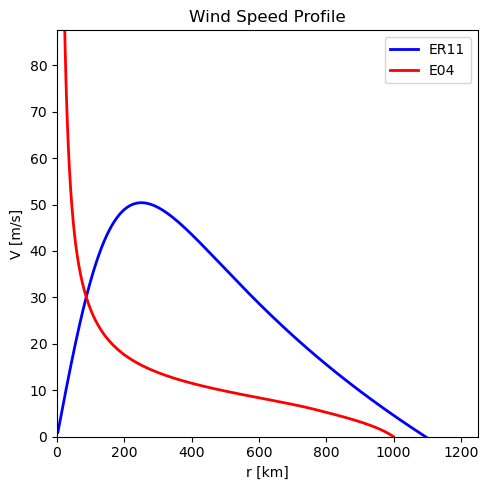

/var/folders/ch/9_p_rc990bzgkvhgv_f_0kr00000gn/T/ipykernel_45683/2918883744.py:274: RuntimeWarning: invalid value encountered in divide
  MMfracMm / rrfracrm


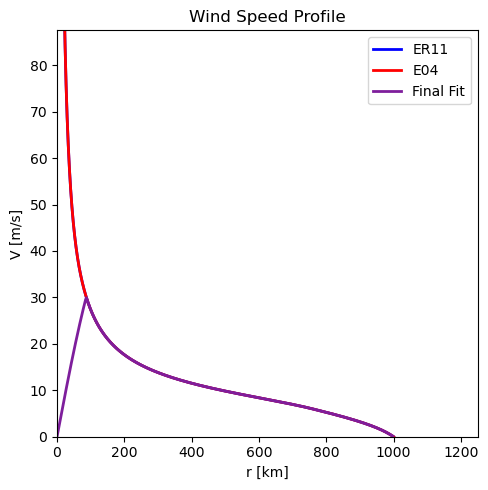

In [7]:
recurision_depth=-1

debugging = debugging
recurision_depth = recurision_depth + 1

# Initialization
coriolis_factor = np.abs(coriolis_factor)

if (CkCdvary == 1) or (CkCdvary is True):
    CkCd_coefquad = 5.5041e-04
    CkCd_coeflin = -0.0259
    CkCd_coefcnst = 0.7627
    CkCd = CkCd_coefquad * v_max ** 2 + CkCd_coeflin * v_max + CkCd_coefcnst
if CkCd > 1.9:
    warnings.warn(
        'Vmax is much greater than the range of data used to estimate CkCd as a function of Vmax -- here be dragons!'
    )
    CkCd = 1.9

# Step 1: Calculate the outer wind profile
outerwind_radii_normalized, outerwind_angular_momentum_array_normalized = outerwind_r0input_nondim_MM0_E04(
    r0, coriolis_factor, Cdvary, C_d, cooling_rate, 100_000
)
outerwind_angular_momentum_array = 0.5 * coriolis_factor * r0 ** 2
M0 = 0.5 * coriolis_factor * r0 ** 2



# Binary search
count = 0
soln_converged = 0

if timeout is not None:
    start_time = time.time()

while soln_converged == 0:
    count += 1


    rmax_new_guess_normalized = (rmax_max_normalized + rmax_min_normalized) / 2.0

    rmaxr0_previous_guess_normalized = rmax_new_guess_normalized
    drmaxr0 = (rmax_max_normalized - rmax_min_normalized) / 2.0

    # Threshold for derivative difference
    drmaxr0_thresh = drmaxr0_thresh # 0.0001


    iterN = 0
    rfracrm_min = 0.0  # [-] start at r=0
    rfracrm_max = 500.0  # [-] extend out to many rmaxs
    while np.abs(drmaxr0) >= drmaxr0_thresh:
        iterN = iterN + 1
        # Calculate ER11 M/Mm vs r/rm
        rmax = rmax_new_guess_normalized * r0  # [m]r
        #     [~,~,rrfracrm_ER11,MMfracMm_ER11] =
        #     ER11_radprof_nondim(Vmax,rmax,fcor,CkCd) #FAILS FOR LOW CK/CD NOT SURE WHY

        # drfracrm = 0.01
        # if rmax > 100.0 * 1000:
        #     drfracrm = drfracrm / 10.0  # extra precision for large storm
        # TODO: Altered to speed things up
        drfracrm = 0.01


        # [] r/r0 vector
        rrfracrm_ER11 = np.arange(rfracrm_min, rfracrm_max + drfracrm, drfracrm)
        rr_ER11 = rrfracrm_ER11 * rmax

        try:
            VV_ER11, dummy = ER11_radprof(v_max, rmax, 'rmax', coriolis_factor, CkCd, rr_ER11)

        except:
            VV_ER11 = np.nan * np.zeros(rr_ER11.size)
        if not np.isnan(np.max(VV_ER11)):  # ER11_radprof converged
            innerwind_radii_normalized = rr_ER11 / r0
            innerwind_angular_momentum_array_normalized = (
                                rr_ER11 * VV_ER11 + (0.5 * coriolis_factor * rr_ER11 ** 2)
                            ) / outerwind_angular_momentum_array

            l1 = LineString(zip(outerwind_radii_normalized, outerwind_angular_momentum_array_normalized))
            l2 = LineString(zip(innerwind_radii_normalized, innerwind_angular_momentum_array_normalized))
            intersection = l1.intersection(l2)
            if (
                'EMPTY' in intersection.wkt
            ):
                # no intersections -- rmaxr0 too small
                # drmaxr0 = np.abs(drmaxr0) / 2
                rmaxr0_previous_guess_normalized = rmax_new_guess_normalized
                rmax_min_normalized = rmaxr0_previous_guess_normalized
                rmax_max_normalized = rmax_max_normalized
                rmax_new_guess_normalized = (rmax_max_normalized + rmax_min_normalized) / 2.0
                drmaxr0 = (rmax_max_normalized - rmax_min_normalized) / 2.0
                if debugging:
                    print('No intersection')
            else:

                # at least one intersection -- rmaxr0 too large
                # drmaxr0 = - np.abs(drmaxr0) / 2
                rmaxr0_previous_guess_normalized = rmax_new_guess_normalized
                rmax_min_normalized = rmax_min_normalized
                rmax_max_normalized = rmaxr0_previous_guess_normalized
                rmax_new_guess_normalized = (rmax_max_normalized + rmax_min_normalized) / 2.0
                drmaxr0 = (rmax_max_normalized - rmax_min_normalized) / 2.0


                if intersection.wkt.split(' ')[0] == 'POINT':
                    X0, Y0 = intersection.coords[0]
                    # then we are very close to the solution or way too big
                    if debugging:
                        print('Points:', X0, Y0)
                elif intersection.wkt.split(' ')[0] == 'MULTIPOINT':
                    X0, Y0 = intersection.geoms[0].coords[0]
                    X1, Y1 = intersection.geoms[-1].coords[0]
                    if debugging:
                        print('Points:', X0, Y0, X1, Y1)

                rmerger0 = np.mean(X0)
                MmergeM0 = np.mean(Y0)


        else:  # ER11_radprof did not converge -- convergence fails for low CkCd and high Ro = Vm/(f*rm)
            ## Must reduce rmax (and thus reduce Ro)
            # drmaxr0 = -abs(drmaxr0) / 2
            rmaxr0_previous_guess_normalized = rmax_new_guess_normalized
            rmax_min_normalized = rmax_min_normalized
            rmax_max_normalized = rmaxr0_previous_guess_normalized
            rmax_new_guess_normalized = (rmax_max_normalized + rmax_min_normalized) / 2.0
            drmaxr0 = (rmax_max_normalized - rmax_min_normalized) / 2.0


        ## update value of rmaxr0
        # rmaxr0_previous_guess_normalized = rmax_new_guess_normalized  # this is the final one
        # rmax_new_guess_normalized = rmax_new_guess_normalized + drmaxr0

        #####################
        if debugging:
            innerwind_radii_normalized = rr_ER11 / r0
            innerwind_angular_momentum_array_normalized = (
                                rr_ER11 * VV_ER11 + (0.5 * coriolis_factor * rr_ER11 ** 2)
                            ) / outerwind_angular_momentum_array

            # Compute the values for plotting
            VV_ = (M0 / r0) * ((innerwind_angular_momentum_array_normalized / innerwind_radii_normalized) - innerwind_radii_normalized)
            rr_E04 = outerwind_radii_normalized * r0
            VV_E04 = (M0 / r0) * ((outerwind_angular_momentum_array_normalized / outerwind_radii_normalized) - outerwind_radii_normalized)


            fig, ax1 = plt.subplots(dpi=100, figsize=(5, 5))

            # Plotting the original data
            ax1.plot(rr_ER11 / 1000, VV_, 'b', linewidth=2, label='ER11')
            ax1.plot(rr_E04 / 1000, VV_E04, 'r', linewidth=2, label='E04')
            ax1.set_xlim(0, r0 * 1.25 / 1000)
            ax1.set_ylim(0, v_max * 1.75)
            ax1.set_xlabel('r [km]')
            ax1.set_ylabel('V [m/s]')
            ax1.set_title('Wind Speed Profile')
            ax1.legend()

            plt.tight_layout()
            plt.show()
            break



    ## Check if the solution converged
    if (not np.isnan(np.max(VV_ER11))) and ('rmerger0' in locals()):
        soln_converged = 1
    else:
        soln_converged = 0
        CkCd = CkCd + 0.1
        if debugging:
            print(f'Adjusting CkCd to find convergence, CkCd: {CkCd}')

        if CkCd > 1.9:
            if recurision_depth > 2:
                print('FAILED')
                print(f'Timed Out. V_max: {v_max}, r0: {r0}, coriolis_factor: {coriolis_factor}', end=' ')
                print(f'Cdvary: {Cdvary}, C_d: {C_d}, cooling_rate: {cooling_rate}', end=' ')
                print(f'CkCdvary: {CkCdvary}, CkCd: {CkCd}, eye_adj: {eye_adj}, alpha_eye: {alpha_eye}')
                print(f'Rmaxr0: {rmax_new_guess_normalized}, Iterations: {iterN}')
                raise TimeoutError('Failed to converge')

            # just restart the fit again
            # call the function again
            raise IndexError
            # return ER11E04_nondim_r0input(
            #     v_max,
            #     r0,
            #     coriolis_factor,
            #     Cdvary=1,
            #     C_d=1.5e-3,
            #     cooling_rate=2e-3,
            #     CkCdvary=0,
            #     CkCd=1,
            #     eye_adj=0,
            #     alpha_eye=0.15,
            #     return_rmax_only=return_rmax_only,
            #     rmax_min_normalized=0.000,
            #     rmax_max_normalized=0.999,
            #     rmaxr0_initial_guess=rmax_new_guess_normalized,
            #     timeout=timeout,
            #     debugging=debugging,
            #     recurision_depth=recurision_depth,
            # )


    if timeout is not None and soln_converged == 0:
        if time.time() - start_time > timeout:
            # print(f'Timed Out. V_max: {v_max}, r0: {r0}, coriolis_factor: {coriolis_factor}', end=' ')
            # print(f'Cdvary: {Cdvary}, C_d: {C_d}, cooling_rate: {cooling_rate}', end=' ')
            # print(f'CkCdvary: {CkCdvary}, CkCd: {CkCd}, eye_adj: {eye_adj}, alpha_eye: {alpha_eye}')
            # print(f'Rmaxr0: {rmax_new_guess_normalized}, Iterations: {iterN}')
            raise TimeoutError

        # print('Adjusting CkCd to find convergence')
# print(f'Converged after {iterN} iterations', iterN)
# if return_rmax_only:
#     return rmax

Mm = 0.5 * coriolis_factor * rmax ** 2 + rmax * v_max
MmM0 = Mm / M0

# Finally: Interpolate to a grid
ii_ER11 = np.argwhere((innerwind_radii_normalized < rmerger0) & (innerwind_angular_momentum_array_normalized < MmergeM0))[:, 0]
ii_E04 = np.argwhere((outerwind_radii_normalized >= rmerger0) & (outerwind_angular_momentum_array_normalized >= MmergeM0))[:, 0]

MMfracM0_temp = np.hstack((innerwind_angular_momentum_array_normalized[ii_ER11], outerwind_angular_momentum_array_normalized[ii_E04]))
rrfracr0_temp = np.hstack((innerwind_radii_normalized[ii_ER11], outerwind_radii_normalized[ii_E04]))
del ii_ER11
del ii_E04

#### PLOT SOME THINGS (DEBUGGING)
# outerwind_radii_normalized, outerwind_angular_momentum_array_normalized
rr_ = rr = outerwind_radii_normalized * r0
VV_ = (M0 / r0) * ((outerwind_angular_momentum_array_normalized / outerwind_radii_normalized) - outerwind_radii_normalized)
# fig, ax = plt.subplots(dpi=100)
# ax.plot(rr_ / 1000, VV_, 'b', linewidth=2, label='E04')
# ax.set_xlim(0, 1050)
# ax.set_ylim(0, 55)
# ax.set_xlabel('r [km]')
# ax.set_ylabel('V [m/s]')
# # ax.set_title('E04')
# # plt.show()
#
# # innerwind_radii_normalized, innerwind_angular_momentum_array_normalized
# rr_ = rr_ER11
# VV_ = (M0 / r0) * ((innerwind_angular_momentum_array_normalized / innerwind_radii_normalized) - innerwind_radii_normalized)
# # fig, ax = plt.subplots(dpi=100)
# ax.plot(rr_ / 1000, VV_, 'r', linewidth=2, label='ER11')
# ax.set_xlim(0, 1050)
# ax.set_ylim(0, 55)
# ax.set_xlabel('r [km]')
# ax.set_ylabel('V [m/s]')
# # ax.set_title('ER11')
# plt.show()

# calculating VV at radii relative to rmax ensures no smoothing near rmax!
drfracrm = (
    0.01
)
rfracrm_min = 0  # [-] r=0
rfracrm_max = r0 / rmax  # [-] r=r0
rrfracrm = np.arange(rfracrm_min, rfracrm_max, drfracrm)  # [] r/r0 vector
f = interp1d(rrfracr0_temp * (r0 / rmax), MMfracM0_temp * (M0 / Mm), fill_value='extrapolate')
MMfracMm = f(rrfracrm)

rrfracr0 = rrfracrm * rmax / r0  # save this as output
MMfracM0 = MMfracMm * Mm / M0

# Calculate dimensional wind speed and radii
VV = (Mm / rmax) * (
    MMfracMm / rrfracrm
) - (0.5 * coriolis_factor * rmax * rrfracrm)  # [ms-1]
rr = rrfracrm * rmax  # [m]

# Make sure V=0 at r=0
VV[rr == 0] = 0

rmerge = rmerger0 * r0
Vmerge = (M0 / r0) * ((MmergeM0 / rmerger0) - rmerger0)  # [ms-1]

# Adjust profile in eye, if desired
# if(eye_adj==1)
# 	r_eye_outer = rmax
# 	V_eye_outer = Vmax
# 	[VV] = radprof_eyeadj(rr,VV,alpha_eye,r_eye_outer,V_eye_outer)
#
#    print('EYE ADJUSTMENT: eye alpha = #3.2f',alpha_eye)

if debugging:
    fig, ax1 = plt.subplots(dpi=100, figsize=(5, 5))

    # Plotting the original data
    ax1.plot(rr_ / 1000, VV_, 'b', linewidth=2, label='ER11')
    ax1.plot(rr_E04 / 1000, VV_E04, 'r', linewidth=2, label='E04')
    ax1.plot(rr / 1000, VV, 'xkcd:purple', linewidth=2, label='Final Fit')
    ax1.set_xlim(0, r0 * 1.25 / 1000)
    ax1.set_ylim(0, v_max * 1.75)
    ax1.set_xlabel('r [km]')
    ax1.set_ylabel('V [m/s]')
    ax1.set_title('Wind Speed Profile')
    ax1.legend()

    plt.tight_layout()
    plt.show()

/var/folders/ch/9_p_rc990bzgkvhgv_f_0kr00000gn/T/ipykernel_45683/1667342363.py:8: RuntimeWarning: invalid value encountered in divide
  VV_ = (M0 / r0) * ((innerwind_angular_momentum_array_normalized / innerwind_radii_normalized) - innerwind_radii_normalized)


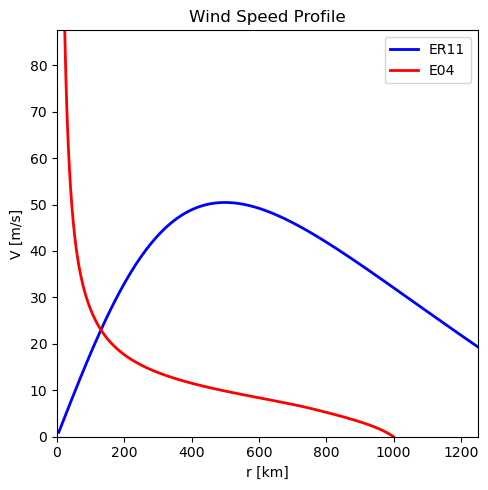

In [6]:
innerwind_radii_normalized = rr_ER11 / r0
innerwind_angular_momentum_array_normalized = (
                    rr_ER11 * VV_ER11 + (0.5 * coriolis_factor * rr_ER11 ** 2)
                ) / outerwind_angular_momentum_array
M0 = 0.5 * coriolis_factor * r0 ** 2

# Compute the values for plotting
VV_ = (M0 / r0) * ((innerwind_angular_momentum_array_normalized / innerwind_radii_normalized) - innerwind_radii_normalized)
rr_E04 = outerwind_radii_normalized * r0
VV_E04 = (M0 / r0) * ((outerwind_angular_momentum_array_normalized / outerwind_radii_normalized) - outerwind_radii_normalized)


fig, ax1 = plt.subplots(dpi=100, figsize=(5, 5))

# Plotting the original data
ax1.plot(rr_ER11 / 1000, VV_, 'b', linewidth=2, label='ER11')
ax1.plot(rr_E04 / 1000, VV_E04, 'r', linewidth=2, label='E04')
ax1.set_xlim(0, r0 * 1.25 / 1000)
ax1.set_ylim(0, v_max * 1.75)
ax1.set_xlabel('r [km]')
ax1.set_ylabel('V [m/s]')
ax1.set_title('Wind Speed Profile')
ax1.legend()

plt.tight_layout()
plt.show()

In [7]:
outerwind_radii_normalized, outerwind_angular_momentum_array_normalized = outerwind_r0input_nondim_MM0_E04(r0, coriolis_factor, Cdvary, C_d, cooling_rate, 100_000) #
# outerwind_angular_momentum_array =



# )
# outerwind_angular_momentum_array = 0.5 * coriolis_factor * r0 ** 2

In [14]:
rr_E04 / 1000
VV_E04


(M0 / r0) * ((outerwind_angular_momentum_array_normalized / outerwind_radii_normalized) - outerwind_radii_normalized)


array([1.82189861e+05, 9.10988306e+04, 6.07351539e+04, ...,
       9.99777522e-04, 4.99925000e-04, 8.32667268e-15])

In [36]:
# rr_ER11 / 1000, VV_


VV_ = (M0 / r0) * ((innerwind_angular_momentum_array_normalized / innerwind_radii_normalized) - innerwind_radii_normalized)

/var/folders/ch/9_p_rc990bzgkvhgv_f_0kr00000gn/T/ipykernel_44295/105167186.py:4: RuntimeWarning: invalid value encountered in divide
  VV_ = (M0 / r0) * ((MMfracM0_ER11 / rrfracr0_ER11) - rrfracr0_ER11)


In [37]:
VV_

array([          nan,    0.92719302,    1.85396199, ..., -621.61823396,
       -621.74385969, -621.86948517])

In [38]:
M0,
r0
innerwind_angular_momentum_array_normalized

array([0.00000000e+00, 2.10438603e-04, 8.41584796e-04, ...,
       3.13051334e+00, 3.13051408e+00, 3.13051483e+00])

In [39]:
innerwind_radii_normalized

array([0.0000e+00, 5.0000e-03, 1.0000e-02, ..., 2.4990e+01, 2.4995e+01,
       2.5000e+01])

In [40]:
innerwind_radii_normalized

array([0.0000e+00, 5.0000e-03, 1.0000e-02, ..., 2.4990e+01, 2.4995e+01,
       2.5000e+01])

In [41]:
from chavas_2015.wind_models import ER11E04_nondim_rmaxinput

rr, VV, rmerge, Vmerge, rmax = ER11E04_nondim_r0input(Vmax,
                                                      r0,
                                                      fcor,
                                                      Cdvary,
                                                      C_d,
                                                      w_cool,
                                                      CkCdvary,
                                                      CkCd,
                                                      eye_adj,
                                                      alpha_eye)




/Users/aaronspaulding/Documents/PycharmProjects/research_spring_2024/chavas_2015/wind_models.py:613: RuntimeWarning: invalid value encountered in divide
  MMfracMm / rrfracrm


In [42]:
r0

1000000

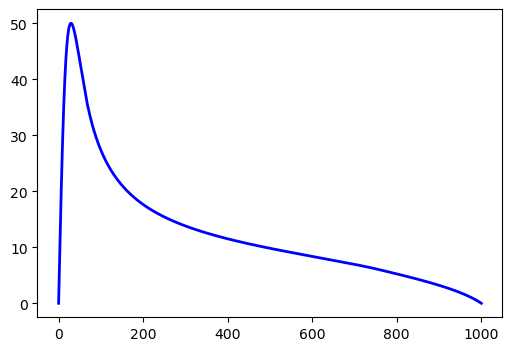

In [43]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=100)

rr = rr / 1000
ax.plot(rr, VV, 'b', linewidth=2, label='Nondim M soln')

plt.show()